<a href="https://colab.research.google.com/github/Nicole2706/nicole2706.github.io/blob/prueba/RandomForestSurvial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aplicacion de Random Forest Survival en el analisis de solvencia de Pymes

In [1]:
!pip install scikit-survival

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 kB 937.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.3/298.3 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.1/220.1 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 52.6 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
from sksurv.ensemble import RandomSurvivalForest
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sksurv.nonparametric import kaplan_meier_estimator



In [4]:
from google.colab import drive

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
ruta = ('/content/drive/MyDrive/tesis/dataset_preprocesado.csv')
df = pd.read_csv(ruta)
pd.set_option('display.max_columns', None)

In [7]:
# 2.1. Eliminar columnas no relevantes
df.drop(columns=['CIF', 'Year', 'min_Year', 'max_Year','Y','FCA'],inplace=True)

#eliminamos los censuarados a la izquierda que son los que al comienzo del estudio ya eran insolventes
df.drop(df[df['time'] < 0].index, inplace=True)



In [8]:
df['F22'].fillna(df['F22'].median(), inplace=True)

<ipython-input-8-1587013123>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['F22'].fillna(df['F22'].median(), inplace=True)


In [26]:
#Convertir 'event' a booleano
df['event'] = df['event'].astype(bool)

In [27]:
# 3. Preparar estructura de supervivencia
# Preparamos los datos
y = np.array(
    [(event, time) for event, time in zip(df['event'], df['time'])],
    dtype=[('event', '?'), ('time', '<f8')])
X = df.drop(columns=['event', 'time'])


In [28]:
# 4. Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

In [64]:
# 5. Entrenar modelo
rsf = RandomSurvivalForest(n_estimators=200,
                           max_depth=15,
                          min_samples_split=20,
                          min_samples_leaf=10,
                          max_features='sqrt',
                          n_jobs=-1,
                          verbose=1,
                          random_state=42)


In [65]:
rsf.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   57.8s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  4.5min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  4.7min finished


RandomSurvivalForest(max_depth=15, min_samples_leaf=10, min_samples_split=20,
                     n_estimators=200, n_jobs=-1, random_state=42, verbose=1)

In [66]:
# 6. Evaluación con datos de entrenamiento
c_index = rsf.score(X_train, y_train)
print(f"Índice de Concordancia (C-index): {c_index:.3f}")

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    0.4s finished


Índice de Concordancia (C-index): 0.901


In [67]:
# 6. Evaluación con datos de prueba
c_index = rsf.score(X_test, y_test)
print(f"Índice de Concordancia (C-index): {c_index:.3f}")

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.5s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.9s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    2.0s finished


Índice de Concordancia (C-index): 0.867


In [69]:
# 5. Análisis de una instancia específica
# Seleccionar una instancia de prueba (ej. la primera)
instance = X_test.iloc[[0]]
print("\nCaracterísticas de la instancia:")
print(instance)
print(y_test[0])


Características de la instancia:
       N1   N2   N3   N4  N5   N6  N7  N8  N9  N10  N11  N12  N13   N14  N15  \
86390   6  9.0  2.0  1.0   0  0.2   0   0   0    0  2.0  2.0  0.0  30.0    0   

           F16       F17       F18       F19       F20       F21       F22  \
86390  2.17837  7.115456  0.835822  1.713976  0.016469  0.025009  0.066133   

            F23       F24    F25       F26       F27       F28       F29  \
86390  0.031162  4.315033  2.154  0.390984 -0.002425  0.007929  0.009487   

            F30       F31         F32       F33       F34       F35       F36  \
86390  0.619003  4.162625  645.462029  8.217735  0.512349  0.712757  0.163413   

            F37       F38       F39       F40       F41  F42  F43  
86390  0.145685  0.328034 -0.003763 -0.256081  0.015326  0.0  0.0  
(True, 7.0)


In [70]:
# 3. Obtener tiempos de evento
times = rsf.event_times_ if hasattr(rsf, 'event_times_') else rsf.unique_times_

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    0.0s finished
<ipython-input-71-2516636134>:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


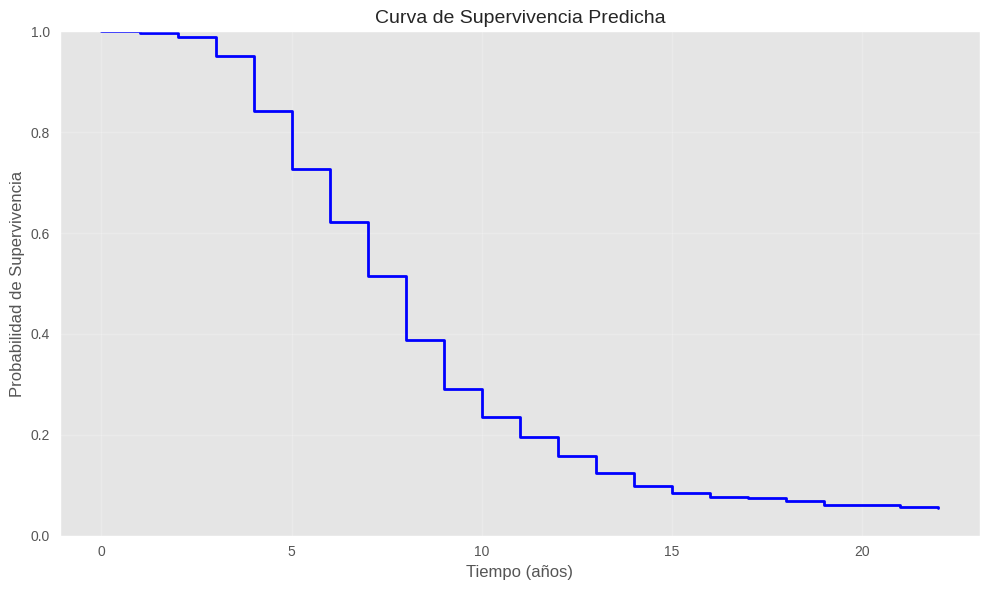

In [71]:
# Predecir función de supervivencia de la instancia
survival_curve = rsf.predict_survival_function(instance, return_array=True)[0]

# Graficar curva de supervivencia de la instancia
plt.figure(figsize=(10, 6))
plt.step(times, survival_curve, where="post", color="blue", linewidth=2)
plt.title("Curva de Supervivencia Predicha")
plt.xlabel("Tiempo (años)")
plt.ylabel("Probabilidad de Supervivencia")
plt.grid(alpha=0.2)

plt.legend()
plt.ylim(0, 1)
plt.show()

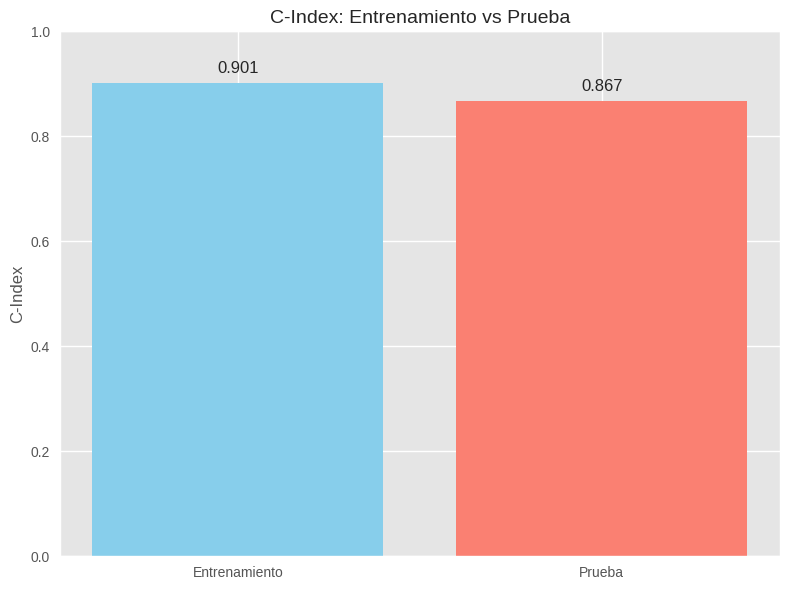

In [72]:

# Datos
categorias = ['Entrenamiento', 'Prueba']
valores = [0.901, 0.867]

# Crear gráfico de barras
plt.figure(figsize=(8, 6))
plt.bar(categorias, valores, color=['skyblue', 'salmon'])
plt.ylim(0, 1)
plt.title('C-Index: Entrenamiento vs Prueba')
plt.ylabel('C-Index')

# Mostrar valores encima de las barras
for i, valor in enumerate(valores):
    plt.text(i, valor + 0.02, f'{valor:.3f}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

In [73]:
# ---------------------------------------------------------------
# ANÁLISIS DE EXPLICABILIDAD
# ---------------------------------------------------------------

# Calcular importancia por permutación
result = permutation_importance(
    rsf,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.5s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    2.0s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    2.1s finished


<ipython-input-74-3323217821>:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(


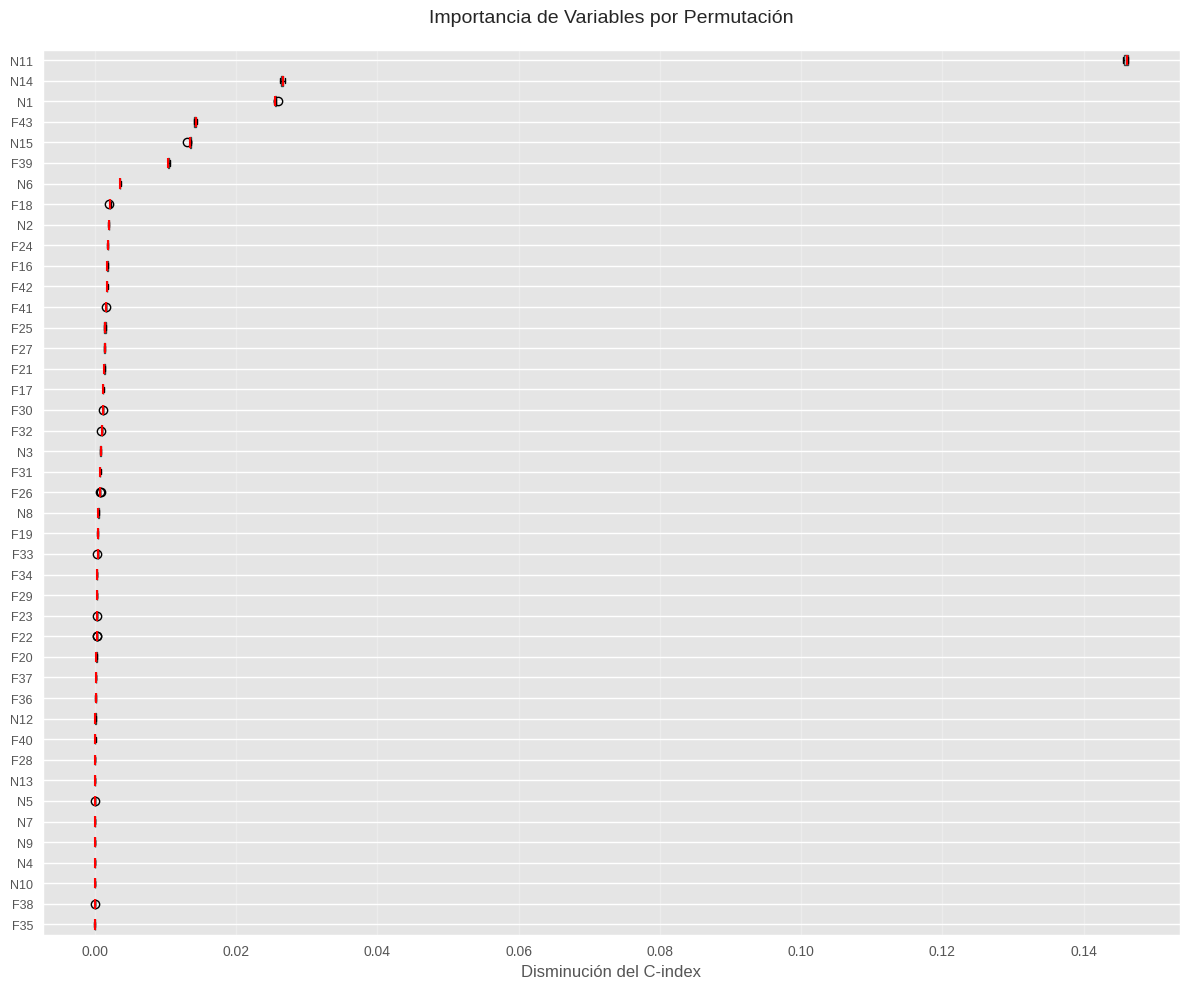

In [74]:
plt.figure(figsize=(12, 10))
sorted_idx = result.importances_mean.argsort()
colors = plt.cm.tab20(np.linspace(0, 1, len(X_test.columns)))

# Boxplot con colores
boxplot = plt.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=X_test.columns[sorted_idx],
    patch_artist=True,
    medianprops={'color': 'red', 'linewidth': 1.5}
)

# Añadir colores a las cajas
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Estilo
plt.title("Importancia de Variables por Permutación", pad=20, fontsize=14)
plt.xlabel("Disminución del C-index", fontsize=12)
plt.yticks(fontsize=9)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Estilos disponibles: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


<ipython-input-75-371465522>:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(
<ipython-input-75-371465522>:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(


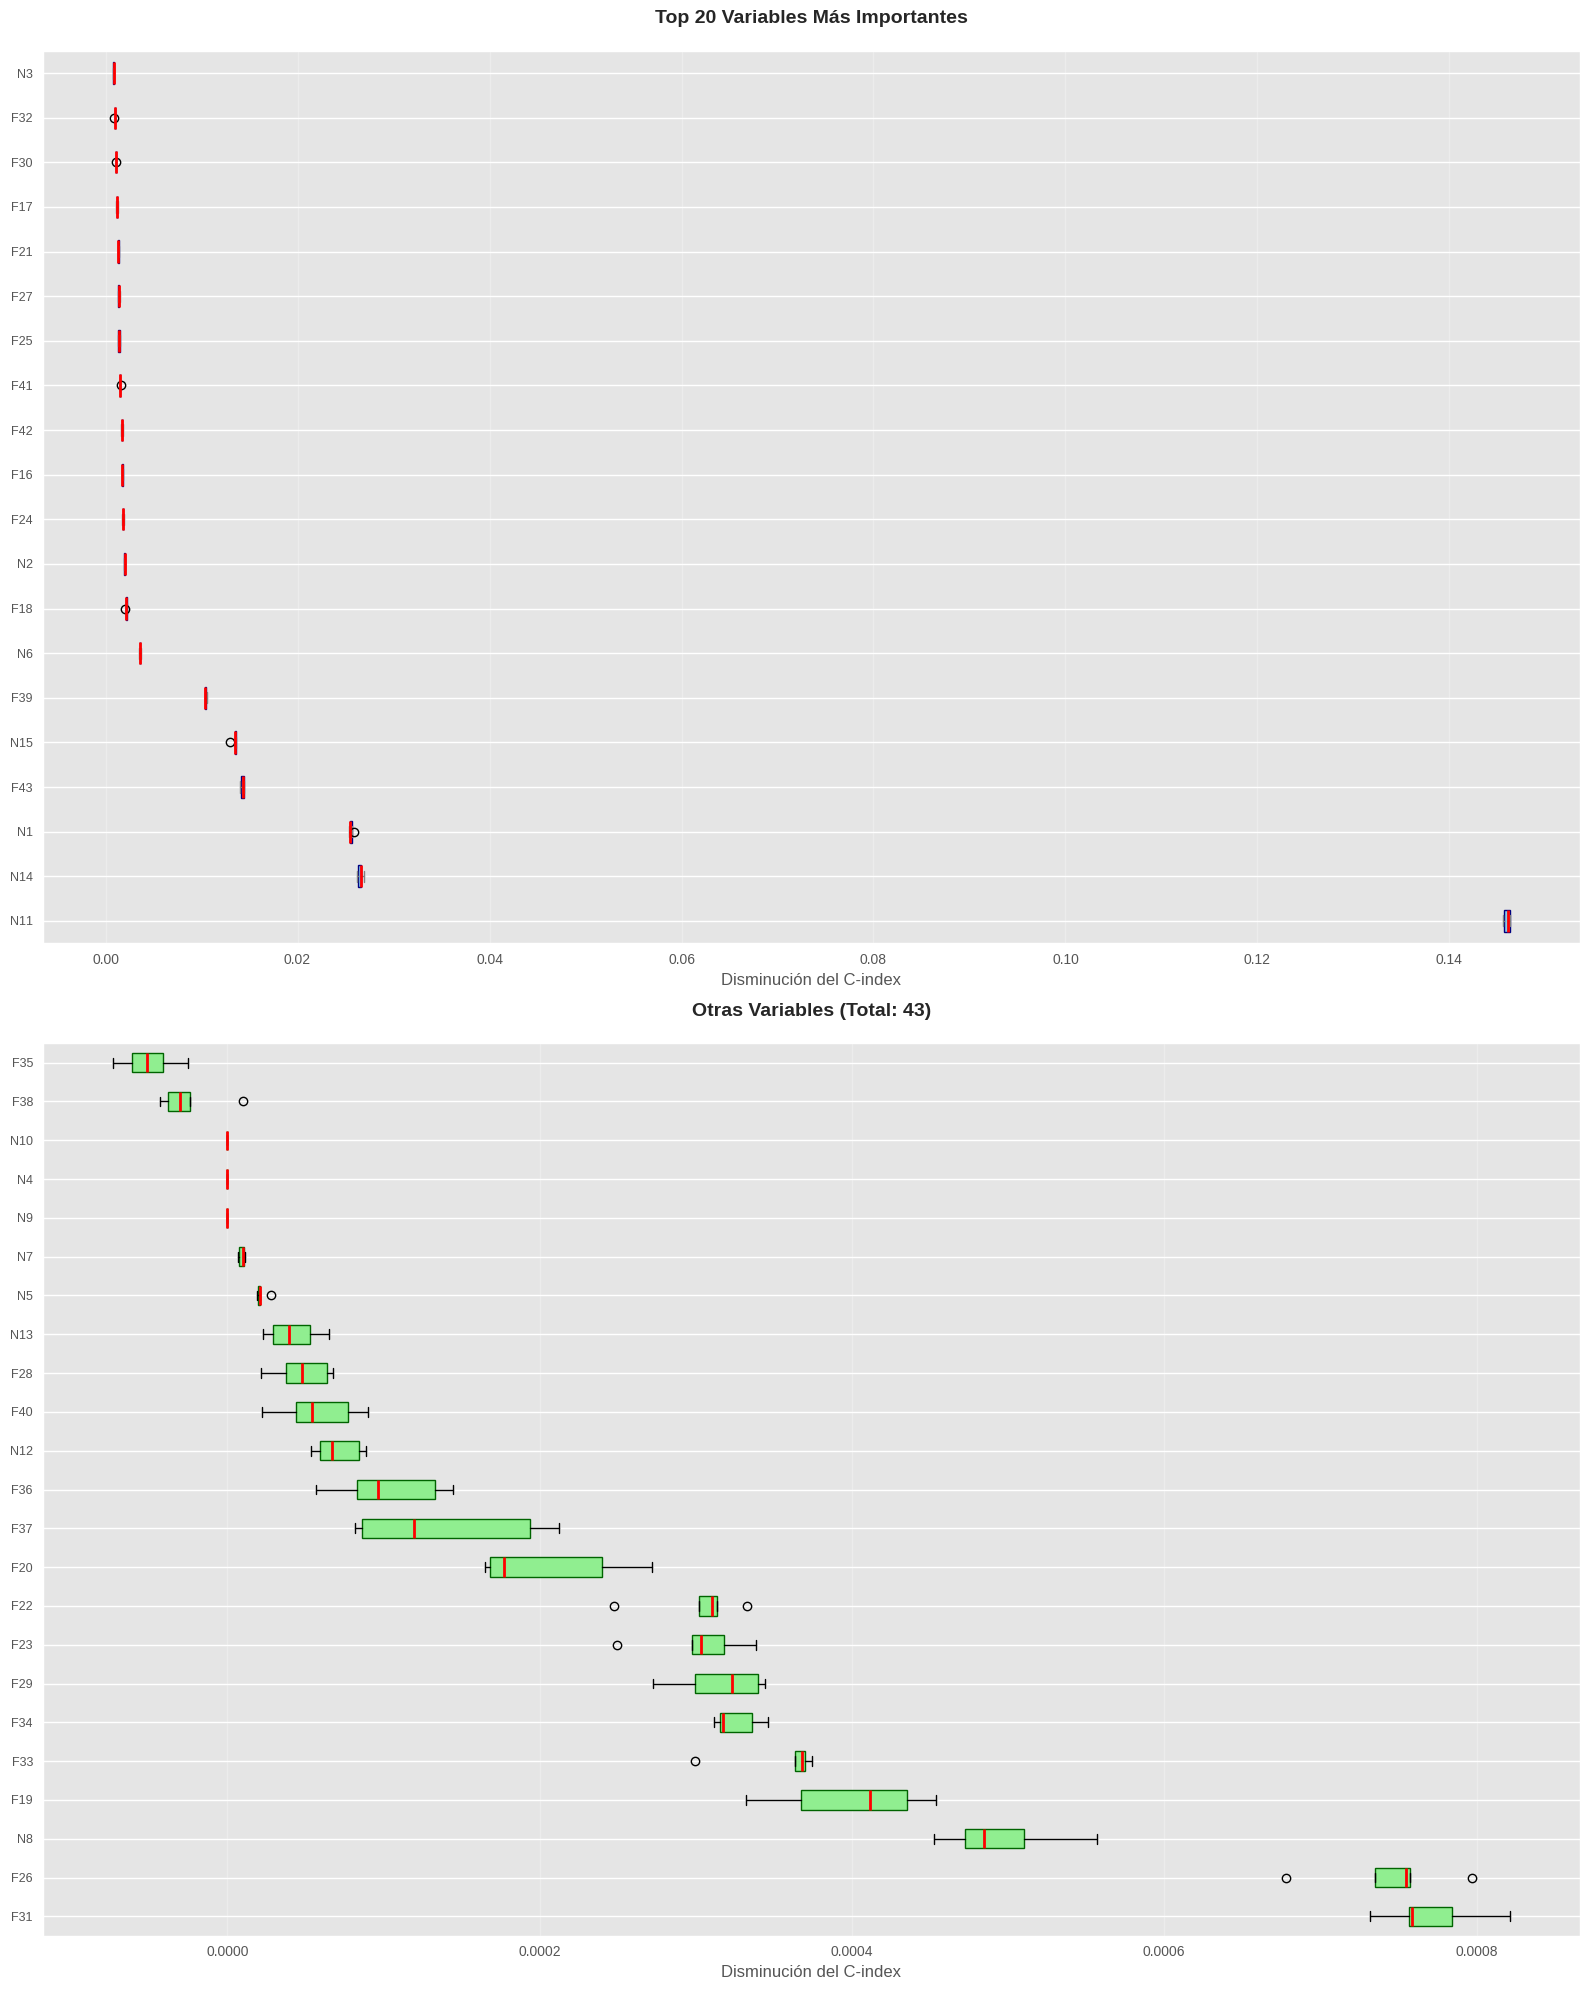

In [75]:
 # Verificar estilos disponibles
print("Estilos disponibles:", plt.style.available)

# Usar un estilo moderno (elige uno de la lista mostrada)
plt.style.use('ggplot')  # Alternativas populares: 'seaborn-v0_8', 'tableau-colorblind10'

# Configuración general
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Ordenar variables por importancia
sorted_idx = result.importances_mean.argsort()[::-1]  # De mayor a menor importancia
features = X_test.columns[sorted_idx]
importance_data = result.importances[sorted_idx].T
importance_means = result.importances_mean[sorted_idx]

# Dividir en top 20 y el resto
top_n = 20
top_features = features[:top_n]
top_data = importance_data[:, :top_n]
rest_features = features[top_n:]
rest_data = importance_data[:, top_n:]

# Crear figura con 2 subplots verticales
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 20))

# --- Gráfico 1: Top 20 variables ---
# Usar colormap moderno
cmap = plt.colormaps['plasma']  # Alternativas: 'viridis', 'cividis', 'magma'
colors_top = cmap(np.linspace(0.2, 0.8, top_n))

ax1.boxplot(
    top_data,
    vert=False,
    labels=top_features,
    patch_artist=True,
    boxprops=dict(facecolor='skyblue', color='navy', linewidth=1),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='gray', linewidth=1),
    capprops=dict(color='gray', linewidth=1)
)

ax1.set_title(f'Top {top_n} Variables Más Importantes', pad=20, fontweight='bold')
ax1.set_xlabel("Disminución del C-index")
ax1.grid(axis='x', alpha=0.3)

# --- Gráfico 2: Resto de variables ---
colors_rest = cmap(np.linspace(0.2, 0.8, len(rest_features)))

ax2.boxplot(
    rest_data,
    vert=False,
    labels=rest_features,
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen', color='darkgreen', linewidth=1),
    medianprops=dict(color='red', linewidth=2)
)

ax2.set_title(f'Otras Variables (Total: {len(features)})', pad=20, fontweight='bold')
ax2.set_xlabel("Disminución del C-index")
ax2.grid(axis='x', alpha=0.3)

# Ajustar diseño
plt.subplots_adjust(hspace=0.5)  # Más espacio entre gráficos

# Rotar etiquetas del eje Y para mejor legibilidad
for ax in [ax1, ax2]:
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)

# Mostrar figura
plt.tight_layout()
plt.show()

In [76]:
!pip install lifelines

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 10.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4119 sha256=88750bb16ec951e970a6bd36a1fbe658625b5596f4e71942e36614e261afb951
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma


In [77]:
from lifelines import KaplanMeierFitter

In [81]:
#Funciones

def momento_critico (model, umbral=0.5):
  #extraemos todas las probabilidades de supervivencia
  probabilidad_sup= model.survival_function_.values.flatten()
  #extraemos todos los tiempos de la función de supervivencia
  time=model.survival_function_.index.values
  #buscamos la primera vez en que la probabilidad de supervivencia es 0.5
  moment= np.where(probabilidad_sup<umbral)[0]
  #Buscamos el año en que la probabilidad fue 0.5
  if len(moment)>0:
      moment_crit=time[moment[0]]
  else:
      moment_crit= None
  return moment,moment_crit,time



def graficar_multiples_modelos(modelos, umbral=0.5):
    """
    Grafica las curvas de supervivencia de varios modelos de Kaplan-Meier en una sola figura,
    incluyendo líneas verticales discontinuas para los momentos críticos.

    Parámetros:
        modelos (dict): Diccionario donde las claves son los nombres de los modelos y los valores
                        son diccionarios con las claves "modelo" (instancia ajustada de KaplanMeierFitter)
                        y "momento_critico" (float o None).
        umbral (float): Umbral de probabilidad a destacar en la gráfica.
    """
     # Validación de entradas
    if not isinstance(modelos, dict):
        raise ValueError("El parámetro 'modelos' debe ser un diccionario.")
    for nombre, datos in modelos.items():
        if not isinstance(datos, dict) or "modelo" not in datos or not isinstance(datos["modelo"], KaplanMeierFitter):
            raise ValueError(f"El modelo '{nombre}' no tiene la estructura esperada.")

    # Crear la figura
    plt.figure(figsize=(10, 6))

    # Colores para las curvas
    colores = plt.cm.tab10.colors  # Paleta de colores predefinida

    # Iterar sobre los modelos y graficar cada uno
    for i, (nombre, datos) in enumerate(modelos.items()):
        modelo = datos["modelo"]
        momento_critico = datos.get("momento_critico", None)
        color = colores[i % len(colores)]  # Asignar un color único

        # Graficar la curva de supervivencia
        modelo.plot_survival_function(label=nombre, color=color)

        # Línea vertical para el momento crítico
        if momento_critico is not None:
            plt.axvline(momento_critico, color=color, linestyle='--', alpha=0.7,
                        label=f"{nombre}: Momento crítico en t = {momento_critico}")
            plt.text(momento_critico, 0.5, f't = {momento_critico}', color=color, ha='right')

    # Línea horizontal para el umbral
    plt.axhline(y=umbral, color='red', linestyle='--', alpha=0.7,
                label=f"Umbral de probabilidad = {umbral}")
    plt.text(max([datos["modelo"].timeline[-1] for datos in modelos.values()]), umbral, f'{umbral}',
             color='red', va='bottom')

    # Personalización del gráfico
    plt.title('Curvas de Supervivencia', fontsize=14)
    plt.xlabel('Tiempo (años)', fontsize=12)
    plt.ylabel('Probabilidad de supervivencia', fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

def procesa(columna):
      columnas=[columna,'event','time']
      df_columna= df.loc[:,columnas]

      print(df[columna].describe())
      df[columna].hist(bins=20)

      media = np.mean(df_columna[columna])

      bajo = df_columna[df_columna[columna] < media]
      alto = df_columna[df_columna[columna] >= media]

      # Crear y ajustar los modelos
      m_bajo = KaplanMeierFitter()
      m_bajo.fit(durations=bajo['time'], event_observed=bajo['event'], label=f'Bajo ({columna} < {media:.6f})')
      moment_bajo, momento_crit_bajo, times_bajo = momento_critico(model=m_bajo)

      m_alto = KaplanMeierFitter()
      m_alto.fit(durations=alto['time'], event_observed=alto['event'], label=f'Alto ({columna} ≥ {media:.6f})')
      moment_alto, momento_crit_alto, times_alto = momento_critico(model=m_alto)

      diccionario = {
          f"Bajo ({columna} < {media:.6f})": {"modelo": m_bajo, "momento_critico": momento_crit_bajo},
          f"Alto ({columna} ≥ {media:.6f})": {"modelo": m_alto, "momento_critico": momento_crit_alto}
      }
      graficar_multiples_modelos(diccionario, umbral=0.5)


Procesando la columna F43
count    117028.000000
mean         -0.014797
std           0.029669
min          -0.066977
25%          -0.030360
50%          -0.008719
75%           0.000000
max           0.045540
Name: F43, dtype: float64


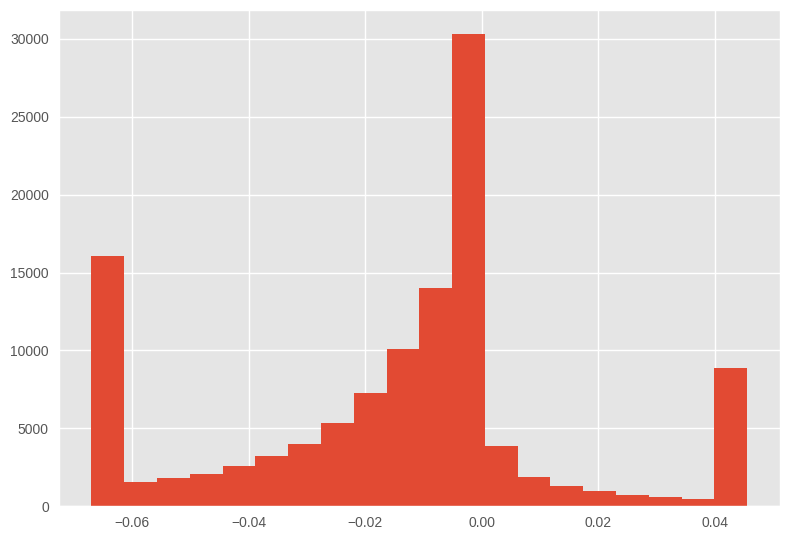

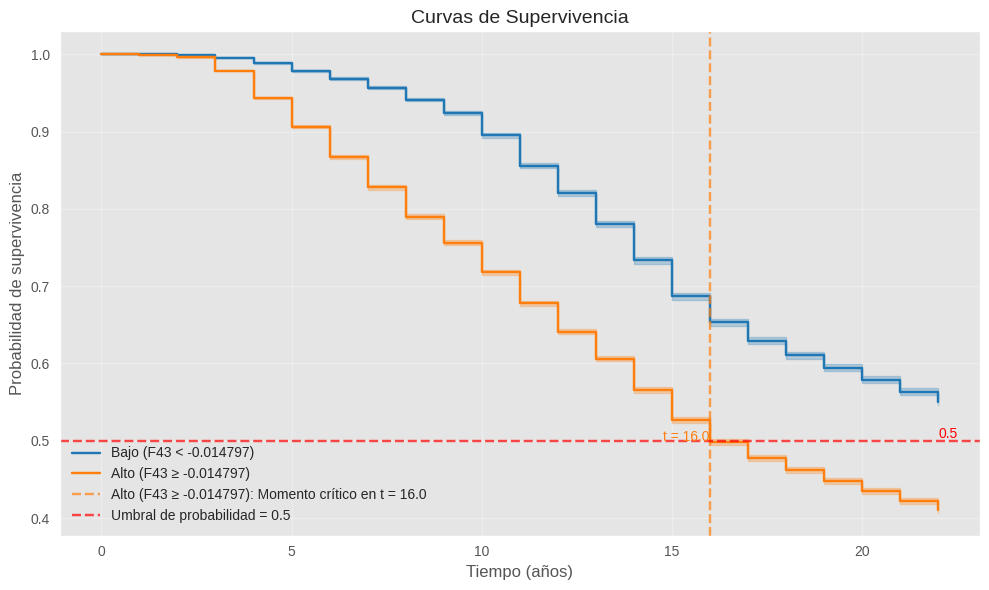

Procesando la columna F39
count    117028.000000
mean          0.067073
std           0.099694
min          -0.167352
25%           0.000000
50%           0.003493
75%           0.111568
max           0.278919
Name: F39, dtype: float64


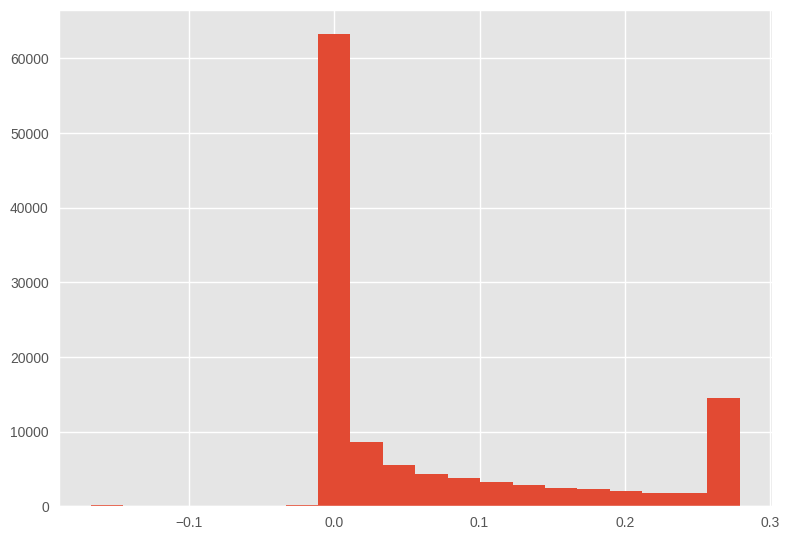

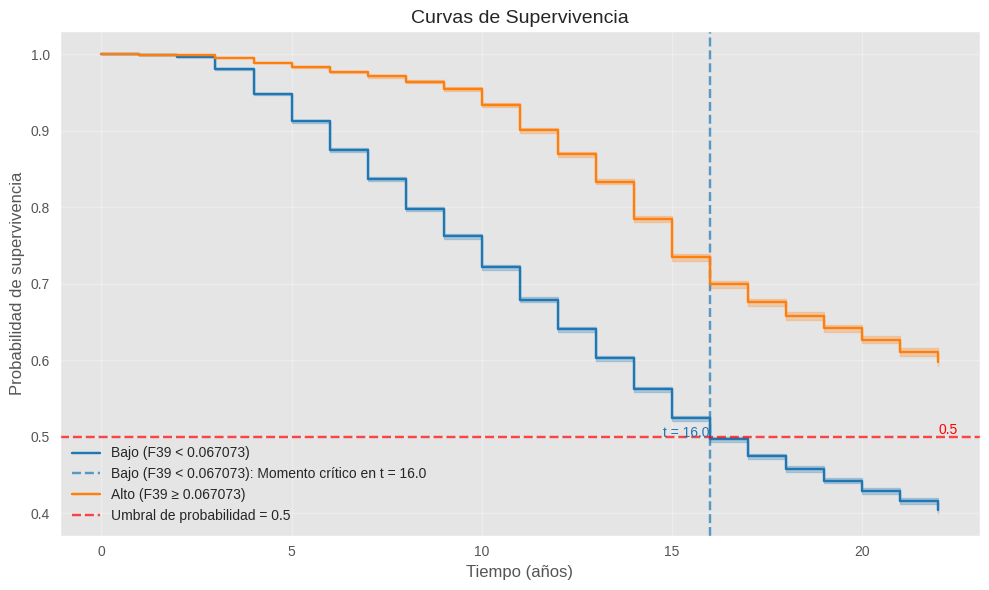

Procesando la columna N14
count    117028.000000
mean         12.116092
std          31.746042
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         327.000000
Name: N14, dtype: float64


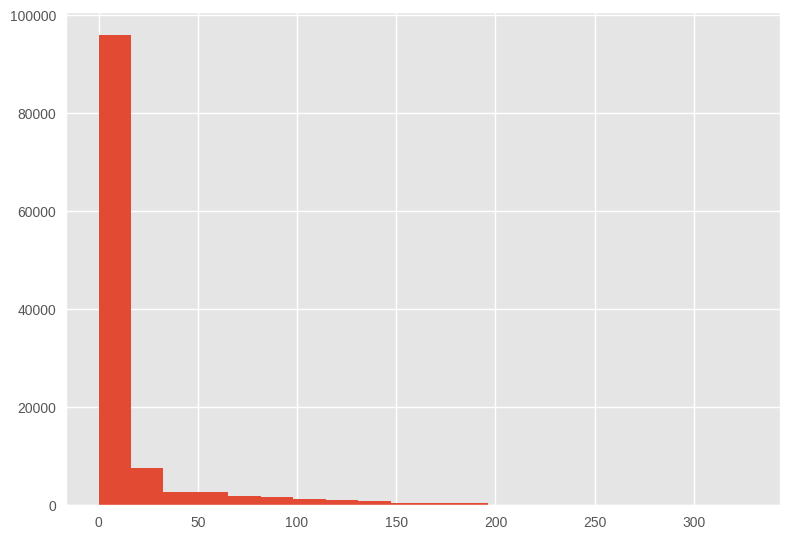

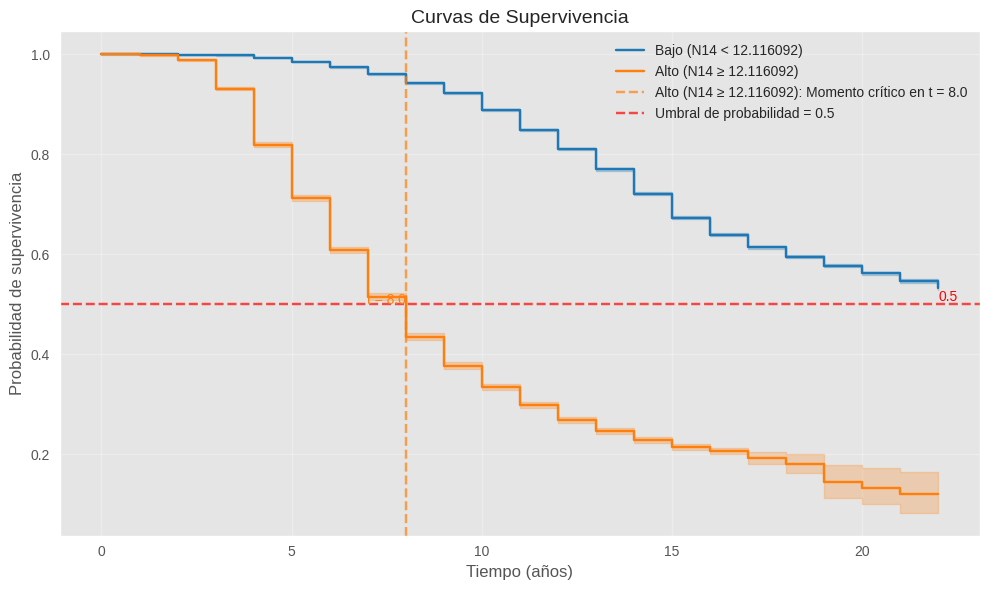

Procesando la columna N6
count    117028.000000
mean          0.168887
std           1.050955
min           0.000000
25%           0.000000
50%           0.000000
75%           0.071429
max         109.647059
Name: N6, dtype: float64


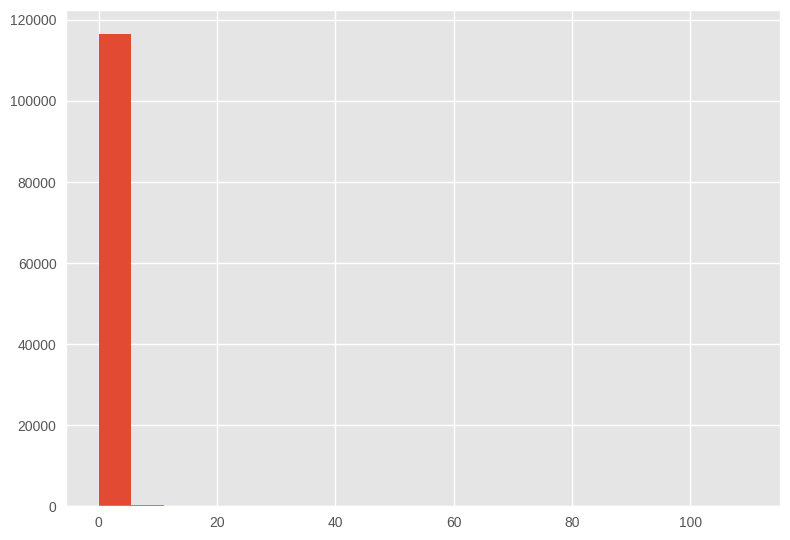

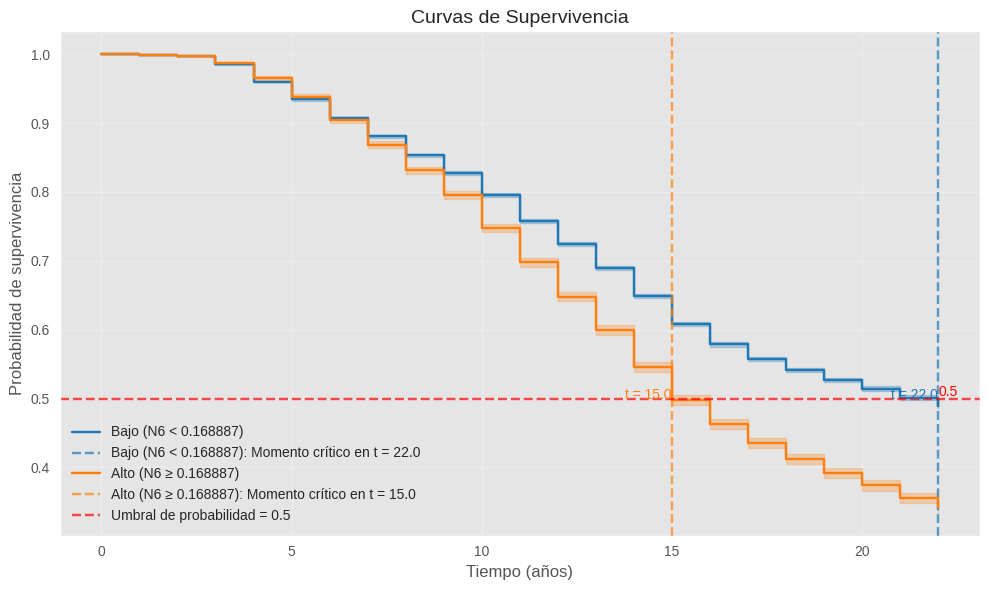

In [82]:
imp_financ= ['F43','F39','N14','N6']
for columna in imp_financ:
    print(f"Procesando la columna {columna}")
    procesa(columna)

<class 'pandas.core.frame.DataFrame'>
Index: 27383 entries, 2 to 117046
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N1      27383 non-null  int64  
 1   event   27383 non-null  bool   
 2   time    27383 non-null  float64
dtypes: bool(1), float64(1), int64(1)
memory usage: 668.5 KB
<class 'pandas.core.frame.DataFrame'>
Index: 83855 entries, 0 to 117051
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N1      83855 non-null  int64  
 1   event   83855 non-null  bool   
 2   time    83855 non-null  float64
dtypes: bool(1), float64(1), int64(1)
memory usage: 2.0 MB


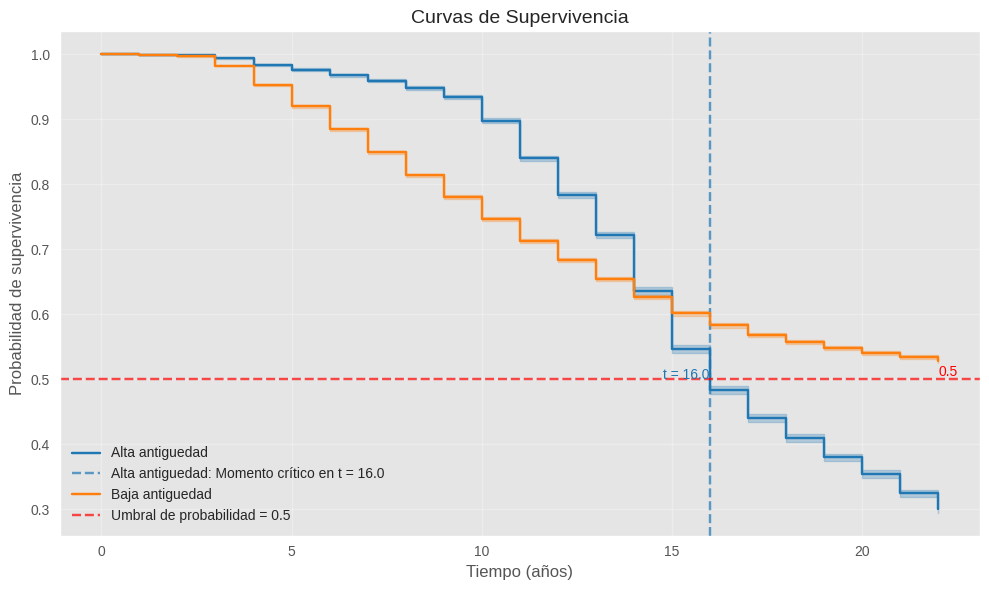

In [83]:
columnas=['N1','event','time']
df_ant= df.loc[:,columnas]
alta_ant= df_ant[df_ant['N1']>df_ant['N1'].quantile(q=0.75)]
alta_ant.info()
baja_ant= df_ant[df_ant['N1']<df_ant['N1'].quantile(q=0.75)]
baja_ant.info()
modelo_alta = KaplanMeierFitter()
modelo_alta.fit(durations=alta_ant['time'],event_observed=alta_ant['event'],label='Alta antiguedad')
moment_a, momento_crit_a, times=momento_critico(model=modelo_alta)

modelo_baja = KaplanMeierFitter()
modelo_baja.fit(durations=baja_ant['time'],event_observed=baja_ant['event'],label='Baja antiguedad')
moment_b, momento_crit_b, times=momento_critico(model=modelo_baja)

antiguedad = {
    "Alta antiguedad":{"modelo":modelo_alta, "momento_critico":momento_crit_a},
    "Baja antiguedad":{"modelo":modelo_baja, "momento_critico":momento_crit_b}
}
graficar_multiples_modelos(antiguedad, umbral=0.5)

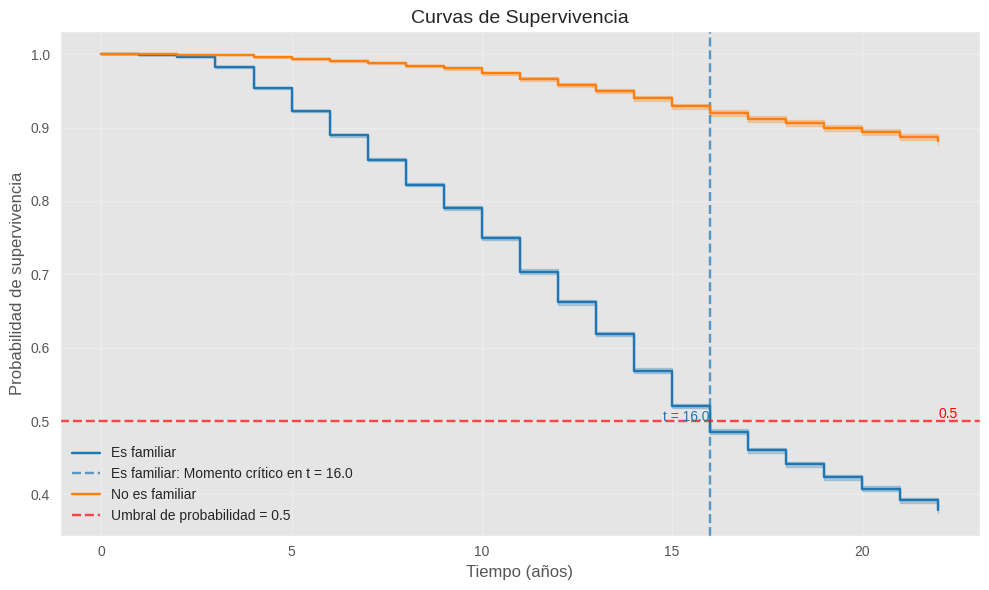

In [84]:
columnas=['N15','event','time']

df_familiar= df.loc[:,columnas]

nofam= df_familiar[df_familiar['N15']==0]
sifam= df_familiar[df_familiar['N15']==1]


modelo_fam=KaplanMeierFitter()
modelo_fam.fit(durations=nofam['time'], event_observed=nofam['event'], label='Empresas no familiares')
moment, momento_crit_a, tiempos=momento_critico(model=modelo_fam)

modelo_nofam=KaplanMeierFitter()
modelo_nofam.fit(durations=sifam['time'], event_observed=sifam['event'], label='Empresas familiares')
moment, momento_crit_b, tiempos=momento_critico(model=modelo_nofam)

fam = {
    "Es familiar":{"modelo":modelo_fam, "momento_critico":momento_crit_a},
    "No es familiar":{"modelo":modelo_nofam, "momento_critico":momento_crit_b}
}

graficar_multiples_modelos(fam, umbral=0.5)

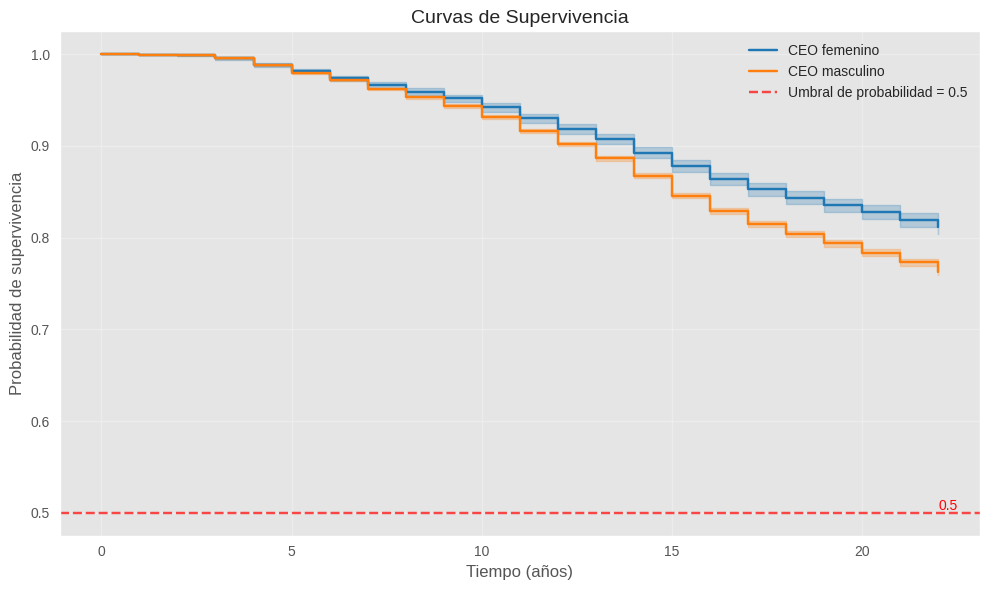

In [85]:
columnas=['N11','event','time']

fem= df[df['N11']==1]
masculino= df[df['N11']==0]

modelo_fem=KaplanMeierFitter()
modelo_fem.fit(durations=fem['time'], event_observed=fem['event'], label='CEO femenino')
moment, momento_crit_a, tiempos=momento_critico(model=modelo_fem)

modelo_masc=KaplanMeierFitter()
modelo_masc.fit(durations=masculino['time'], event_observed=masculino['event'], label='CEO masculino')
moment, momento_crit_b, tiempos=momento_critico(model=modelo_masc)

ceo = {
    "CEO femenino":{"modelo":modelo_fem, "momento_critico":momento_crit_a},
    "CEO masculino":{"modelo":modelo_masc, "momento_critico":momento_crit_b}
}

graficar_multiples_modelos(ceo, umbral=0.5)